In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [8]:
with rasterio.open("C:/Data/grazing_study_drone_data/p4m_wc1_20240306_mosaic.tif") as src:
    blue = src.read(1).astype(np.uint16)
    green = src.read(2).astype(np.uint16)
    red = src.read(3).astype(np.uint16)
    rededge = src.read(4).astype(np.uint16)
    nir = src.read(5).astype(np.uint16)

nodata_value = 65535
blue = np.ma.masked_equal(blue, nodata_value)
green = np.ma.masked_equal(green, nodata_value)
red = np.ma.masked_equal(red, nodata_value)
rededge = np.ma.masked_equal(rededge, nodata_value)
nir = np.ma.masked_equal(nir, nodata_value)

print(np.min(blue), np.max(blue))

3908 65534


In [3]:
nodata_value = 65535

valid_mask = (
    (blue != nodata_value) &
    (green != nodata_value) &
    (red != nodata_value) &
    (nir != nodata_value)
)

print("Valid pixels:", np.sum(valid_mask))
print("Percent valid:", 100 * np.sum(valid_mask) / valid_mask.size)

Valid pixels: 137554986
Percent valid: 60.10026878111745


In [4]:
blue_clean = np.where(valid_mask, blue, np.nan).astype("float32")
green_clean = np.where(valid_mask, green, np.nan).astype("float32")
red_clean = np.where(valid_mask, red, np.nan).astype("float32")
nir_clean = np.where(valid_mask, nir, np.nan).astype("float32")

In [31]:
import os
import sys
import argparse
import glob
from osgeo import gdal

gdal.UseExceptions()
np.seterr(divide='ignore', invalid='ignore')

ndvi = (nir_clean - red_clean) / (nir_clean + red_clean)

ndvi = np.where(np.isfinite(ndvi), ndvi, np.nan)


print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))

NDVI min: -0.6431506
NDVI max: 0.8105257


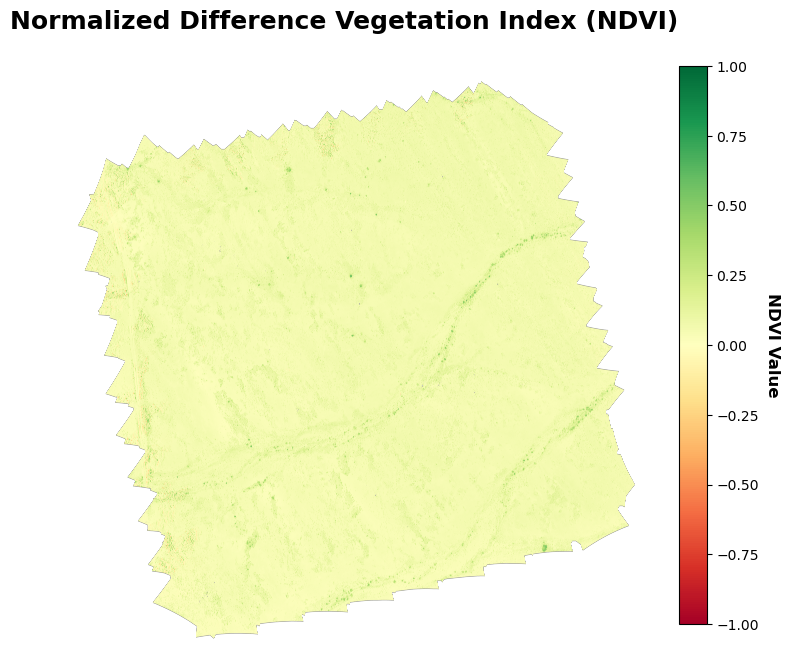

In [33]:
from matplotlib.colors import TwoSlopeNorm

min_val = -1
max_val = 1
mid_val = 0

colormap = plt.cm.RdYlGn
norm = TwoSlopeNorm(vmin=min_val, vcenter=mid_val, vmax=max_val)

fig, ax = plt.subplots(figsize=(10, 8))

img = ax.imshow(ndvi, cmap=colormap, norm=norm)

ax.axis('off')
ax.set_title('Normalized Difference Vegetation Index (NDVI)', fontsize=18, fontweight='bold')

cbar = fig.colorbar(img, ax=ax, fraction=0.036, pad=0.04)
cbar.set_label('NDVI Value', rotation=270, labelpad=15, fontsize=12, fontweight='bold')

plt.show()

In [20]:

slopeNirRed = abs(nir_clean - red_clean) / 190 # 190 is the difference of center wavelength for nir and red
slopeGreenBlue = abs(green_clean - blue_clean) / 110  # 110 is the difference of center wavelength for green and blue

ssi = (slopeNirRed - slopeGreenBlue) / (slopeNirRed + slopeGreenBlue)

ssi = np.where(np.isfinite(ssi), ssi, np.nan)

print("SSI min:", np.nanmin(ssi))
print("SSI max:", np.nanmax(ssi))
print("SSI valid count:", np.sum(~np.isnan(ssi)))

SSI min: -1.0
SSI max: 1.0
SSI valid count: 137554986


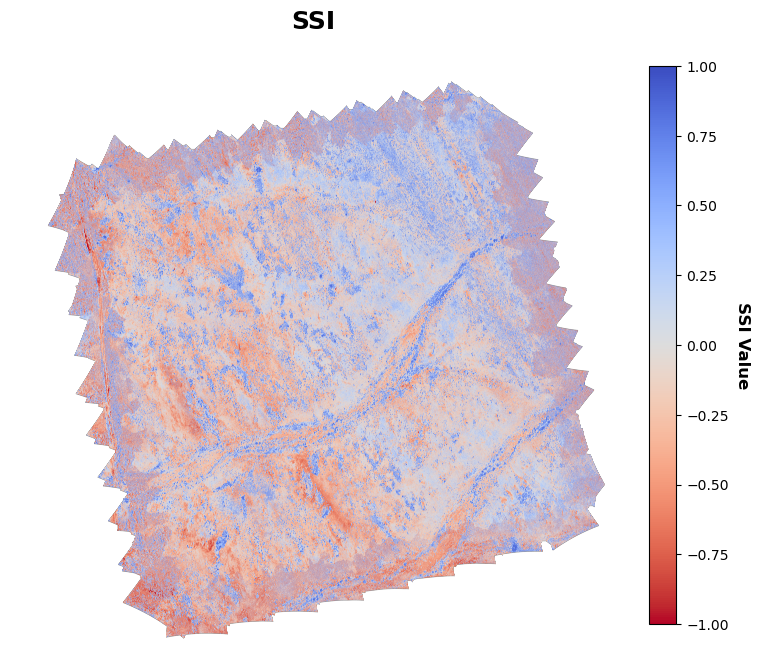

In [21]:
from matplotlib.colors import TwoSlopeNorm

min_val = -1
max_val = 1
mid_val = 0

colormap = plt.cm.coolwarm_r # Blue is closer to NPV, Red is closer to BS
norm = TwoSlopeNorm(vmin=min_val, vcenter=mid_val, vmax=max_val)

fig, ax = plt.subplots(figsize=(10, 8))

img = ax.imshow(ssi, cmap=colormap, norm=norm)

ax.axis('off')
ax.set_title('SSI', fontsize=18, fontweight='bold')

cbar = fig.colorbar(img, ax=ax, fraction=0.036, pad=0.04)
cbar.set_label('SSI Value', rotation=270, labelpad=15, fontsize=12, fontweight='bold')

plt.show()

In [34]:
x = ndvi[valid_mask]
y = ssi[valid_mask]

print("Flattened valid pixels:", len(x))
print("NDVI range:", np.nanmin(x), "to", np.nanmax(x))
print("SSI range:", np.nanmin(y), "to", np.nanmax(y))

Flattened valid pixels: 137554986
NDVI range: -0.6431506 to 0.8105257
SSI range: -1.0 to 1.0


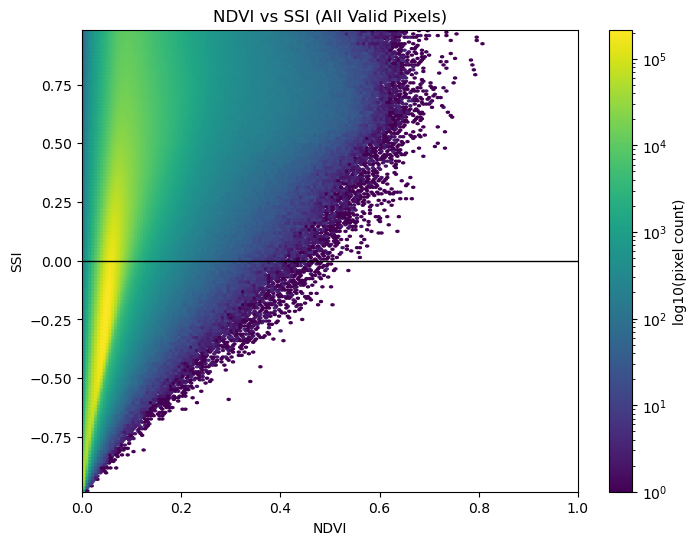

In [35]:
ymax = np.nanpercentile(np.abs(y), 99.5)

plt.figure(figsize=(8, 6))
plt.hexbin(x, y, gridsize=250, mincnt=1, bins="log")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("NDVI")
plt.ylabel("SSI")
plt.title("NDVI vs SSI (All Valid Pixels)")
plt.xlim(0, 1)
plt.ylim(-ymax, ymax)

cb = plt.colorbar()
cb.set_label("log10(pixel count)")

plt.show()

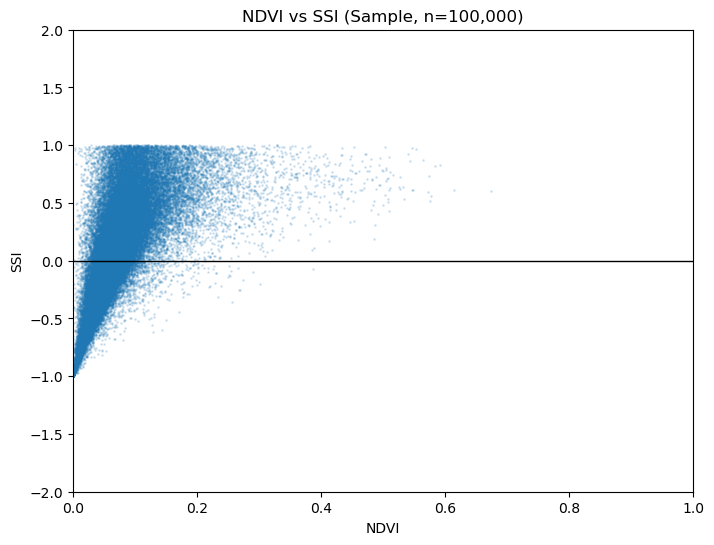

In [36]:
sample_size = 100000

if len(x) > sample_size:
    idx = np.random.choice(len(x), sample_size, replace=False)
    x_sample = x[idx]
    y_sample = y[idx]
else:
    x_sample = x
    y_sample = y

plt.figure(figsize=(8, 6))
plt.scatter(x_sample, y_sample, s=1, alpha=0.15)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("NDVI")
plt.ylabel("SSI")
plt.title(f"NDVI vs SSI (Sample, n={len(x_sample):,})")
plt.xlim(0, 1)
plt.ylim(-2, 2)
plt.show()